# 04 — GMxB Deep Hedging & Model Risk

> **The core result.** A standard deep hedge (SDH) is trained on a **calibrated**
> variable-annuity world — Heston vol, Vasicek rates, stochastic mortality — and then
> evaluated under **shifted** worlds. The surfaces show how the hedge's P&L degrades as
> the realised world drifts from calibration. The headline: **equity volatility is the
> dominant model risk; rates are second; mortality a distant third.**

This notebook (1) shows the deep hedge produces correct, interpretable holdings across
the whole GM(A/W/D)B family — every product, every floor, with/without lapse, with
mortality — and (2) uses that machinery for a controlled, two-dimensional map of the
hedge's model risk.

> Budgets are showcase-scale (≈90–160 epochs) so shapes and surface geometry are clean;
> raise epochs for paper-grade convergence.

In [1]:
# ── setup: the GMxB deep-hedge engine (standard deep hedge, current API) ──
import os, sys

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
SRC = os.path.join(ROOT, "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import math
from types import SimpleNamespace as NS

import numpy as np
import torch

import qabit as qb
from qabit.core.market.curve import (
    StochasticDiscountCurve,
    StochasticHazardCurve,
    MarketKeys,
)
from qabit.core.nn import (
    DeepHedger,
    HedgingMLP,
    FeatureSet,
    Moneyness,
    TimeToMaturity,
    InstantaneousVol,
    ShortRate,
    HazardRate,
    Survival,
    PrevHoldings,
    FixedHedge,
    ResetHedge,
    VarianceLoss,
    GuaranteeMoneyness,
    AnniversaryPhase,
    Deceased,
    PendingDeathBenefit,
    MortalityLiveness,
)
from qabit.core.products.derivatives.va import (
    GMABAnnuity,
    GMWBAnnuity,
    GMDBAnnuity,
    GuaranteeFloor,
    Fixed,
    RollUp,
    Ratchet,
    Reset,
)

torch.set_num_threads(4)


# ─────────────────────────────────────────────────────────────────────────────
# Worlds
# ─────────────────────────────────────────────────────────────────────────────
def make_regime(
    name,
    equity="gbm",
    rate="flat",
    hazard=None,
    sigma=0.18,
    r=0.03,
    s0=1.0,
    # Heston knobs
    h_kappa=2.0,
    h_theta=None,
    h_xi=0.30,
    h_rho=-0.7,
    h_v0=None,
    # Vasicek knobs
    v_kappa=0.5,
    v_theta=None,
    v_sigma=0.01,
    v_r0=None,
    # CIR-Gompertz mortality knobs
    m_m=80.0,
    m_b=9.5,
    m_age=60.0,
    m_kappa=0.5,
    m_sigma=0.03,
):
    """A simulated world (SDESystem) + the Market that prices against it."""
    f = {}
    if rate == "flat":
        f["rate"] = qb.ConstantRateFactor(rate=r)
    else:
        f["rate"] = qb.VasicekRateFactor(
            kappa=v_kappa,
            theta=r if v_theta is None else v_theta,
            sigma=v_sigma,
            r0=r if v_r0 is None else v_r0,
        )
    if equity == "gbm":
        f["eq"] = qb.GeometricBrownianFactor(sigma=sigma, s0=s0, rate="rate")
    else:  # heston
        f["eq"] = qb.HestonFactor(
            kappa=h_kappa,
            theta=sigma**2 if h_theta is None else h_theta,
            xi=h_xi,
            rho=h_rho,
            s0=s0,
            v0=sigma**2 if h_v0 is None else h_v0,
            rate="rate",
        )
    if hazard:
        f["mort"] = (
            qb.GompertzHazardFactor(m=m_m, b=m_b, entry_age=m_age)
            if hazard == "det"
            else qb.CIRGompertzHazardFactor(
                m=m_m, b=m_b, entry_age=m_age, kappa=m_kappa, sigma_lam=m_sigma
            )
        )
    sde = qb.SDESystem(f)
    market = qb.Market(
        discount={
            "ois": qb.DiscountCurve.flat(r)
            if rate == "flat"
            else StochasticDiscountCurve(sde["rate"])
        },
        volatility={"v": qb.VolSurface.flat(sigma)},
        hazard={"mort": StochasticHazardCurve(sde["mort"])} if hazard else {},
    )
    bits = [f"{rate} rate", "heston vol" if equity == "heston" else "flat vol"]
    if hazard:
        bits.append(f"{hazard} hazard")
    return NS(
        name=name,
        system=sde,
        market=market,
        stock=qb.Stock(sde["eq"], cost=0.0),
        fund=sde["eq"],
        sigma=sigma,
        r=r,
        hazard=hazard,
        label=f"{name} · " + " / ".join(bits),
    )


# ─────────────────────────────────────────────────────────────────────────────
# Hedge ladder + features
# ─────────────────────────────────────────────────────────────────────────────
def make_legs(
    stock, *, tenor=0.5, cost=0.0, puts=(("ATM put", 1.00), ("ITM put", 1.05))
):
    legs, labels = [FixedHedge(stock, cost=cost)], ["stock"]
    for lab, alpha in puts:

        def make_inner(level, t0, _th=tenor):
            return qb.EuropeanOption(
                stock, strike=level, maturity=t0 + _th, is_call=False, cost=cost
            )

        legs.append(ResetHedge(make_inner, stock, alpha=alpha, tenor=tenor, cost=cost))
        labels.append(lab)
    return legs, labels


def gmab_features(reg, n_legs):
    feats = [Moneyness(), TimeToMaturity(), InstantaneousVol(), ShortRate(), GuaranteeMoneyness(), PrevHoldings(n_inst=n_legs)]
    if reg.hazard:
        feats += [Deceased(), PendingDeathBenefit(), HazardRate(), Survival()]
    return FeatureSet(feats)


# ─────────────────────────────────────────────────────────────────────────────
# Train + diagnose
# ─────────────────────────────────────────────────────────────────────────────
def train_hedger(
    reg,
    gm,
    *,
    T=10.0,
    tenor=0.5,
    rebal_dt=1 / 12,
    n_paths=2048,
    n_epochs=120,
    lr=1e-3,
    seed=42,
    diag_paths=8000,
    cost=0.0,
    verbose=False,
):
    legs, labels = make_legs(reg.stock, tenor=tenor, cost=cost)
    feats = gmab_features(reg, len(legs))
    has_mort = getattr(gm.marketkeys, "hazard", None) is not None
    liveness = MortalityLiveness() if has_mort else None
    hed = DeepHedger(
        HedgingMLP(feats.total_dim, n_hedges=len(legs)),
        feats,
        legs,
        VarianceLoss(),
        liability=lambda t, m: t.price(m)[0],
        liveness=liveness,
    )
    cal = qb.EventCalendar.from_horizon(T + tenor, rebal_dt)
    rebal = torch.arange(0.0, T + 1e-9, rebal_dt)
    hist = hed.fit(
        gm,
        system=reg.system,
        calendar=cal,
        rebalance_dates=rebal,
        market=reg.market,
        n_paths=n_paths,
        n_epochs=n_epochs,
        lr=lr,
        seed=seed,
        verbose=verbose,
    )
    d = hed.diagnose(
        gm,
        system=reg.system,
        calendar=cal,
        rebalance_dates=rebal,
        market=reg.market,
        n_paths=diag_paths,
        seed=seed + 777,
    )
    net = d["pnl"] - d["tc"]
    return NS(
        hedger=hed,
        diag=d,
        rebal=rebal,
        cal=cal,
        T=T,
        tenor=tenor,
        reg=reg,
        target=gm,
        labels=labels,
        hist=hist,
        mean_pnl=float(net.mean()),
        var_kept=float(net.std() / d["liability"].std()) ** 2,
    )


def diagnose_under(res, reg2, gm2, *, diag_paths=8000, seed=4242):
    """Evaluate an ALREADY-TRAINED policy under a DIFFERENT world (reg2, gm2).

    The model-risk move: the MLP (incl. its calibrated input standardiser) is
    trained on res.reg, but the paths come from reg2 with shifted parameters.
    We rebuild the ladder/features/target on reg2 and transfer the trained
    weights — no retraining, pure forward pass.  gm2 must have the same contract
    terms (hence the same feature dimension) as the trained contract.
    """
    legs, labels = make_legs(reg2.stock, tenor=res.tenor)
    feats = gmab_features(reg2, len(legs))
    has_mort = getattr(gm2.marketkeys, "hazard", None) is not None
    liveness = MortalityLiveness() if has_mort else None
    hed2 = DeepHedger(
        HedgingMLP(feats.total_dim, n_hedges=len(legs)),
        feats,
        legs,
        VarianceLoss(),
        liability=lambda t, m: t.price(m)[0],
        liveness=liveness,
    )
    hed2.model.load_state_dict(res.hedger.model.state_dict())
    d = hed2.diagnose(
        gm2,
        system=reg2.system,
        calendar=res.cal,
        rebalance_dates=res.rebal,
        market=reg2.market,
        n_paths=diag_paths,
        seed=seed,
    )
    net = d["pnl"] - d["tc"]
    return NS(
        diag=d,
        reg=reg2,
        mean_pnl=float(net.mean()),
        std_pnl=float(net.std()),
        var_kept=float(net.std() / d["liability"].std()) ** 2,
        net=net.numpy(),
        liability=d["liability"].numpy(),
    )


# ─────────────────────────────────────────────────────────────────────────────
# Contract builders (identical terms across worlds)
# ─────────────────────────────────────────────────────────────────────────────
P_DEF = 1.0
FLOORS = {
    "fixed": lambda P: GuaranteeFloor([Fixed()], G0=P),
    "ratchet": lambda P: GuaranteeFloor([Ratchet()], G0=P),
    "reset": lambda P: GuaranteeFloor([Reset(dates=[3.0, 6.0])], G0=P),
    "rollup": lambda P: GuaranteeFloor([RollUp(0.03)], G0=P),
}


def build_contract(reg, product, floor, *, P=P_DEF, T=10.0, mixed=False, p_S=0.02):
    """Build a GM(A/W/D)B with the given living/death floor on world `reg`."""
    hz = "mort" if reg.hazard else None
    mk = MarketKeys(discount="ois", hazard=hz)
    fl = FLOORS[floor](P)
    if product == "GMAB":
        gm = GMABAnnuity(
            fund=reg.fund,
            living_floor=fl,
            premium=P,
            maturity=T,
            marketkeys=mk,
            seed=20240601,
            **(
                {"surrender_floor": GuaranteeFloor([Fixed()], G0=P), "p_S": p_S}
                if mixed
                else {}
            ),
        )
    elif product == "GMWB":
        gm = GMWBAnnuity(
            fund=reg.fund,
            living_floor=fl,
            premium=P,
            maturity=T,
            marketkeys=mk,
            seed=20240601,
            **(
                {"surrender_floor": GuaranteeFloor([Fixed()], G0=P), "p_S": p_S}
                if mixed
                else {}
            ),
        )
    elif product == "GMDB":
        # GMDB: pure death rider — living floor degenerate, guarantee on the death floor.
        gm = GMDBAnnuity(
            fund=reg.fund,
            living_floor=GuaranteeFloor.zero(),
            death_floor=fl,
            premium=P,
            maturity=T,
            marketkeys=mk,
            seed=20240601,
            **(
                {"surrender_floor": GuaranteeFloor([Fixed()], G0=P), "p_S": p_S}
                if mixed
                else {}
            ),
        )
    else:
        raise ValueError(product)
    if mixed:
        gm.list_mixed()
    return gm


def build_skeleton(reg, *, T=10.0, tenor=0.5, rebal_dt=1 / 12):
    legs, labels = make_legs(reg.stock, tenor=tenor)
    feats = gmab_features(reg, len(legs))
    has_mort = getattr(reg, "hazard", None) is not None
    hed = DeepHedger(
        HedgingMLP(feats.total_dim, n_hedges=len(legs)),
        feats,
        legs,
        VarianceLoss(),
        liability=lambda t, m: t.price(m)[0],
        liveness=MortalityLiveness() if has_mort else None,
    )
    cal = qb.EventCalendar.from_horizon(T + tenor, rebal_dt)
    rebal = torch.arange(0.0, T + 1e-9, rebal_dt)
    return NS(
        hedger=hed, cal=cal, rebal=rebal, tenor=tenor, T=T, reg=reg, labels=labels
    )


def gmab_state(res, k=None, gm=None):
    """(A_t, G_t, d1, k, tau) at step k from the contract's own floor recursion."""
    gm = gm or res.target
    H = res.diag["holdings"]
    k = H.shape[1] // 2 if k is None else k
    t = float(res.diag["open_times"][k])
    paths = gm._paths(res.reg.market)
    anniv = [float(a) for a in paths["anniv"]]
    j = max(i for i, a in enumerate(anniv) if a <= t + 1e-9)
    S = (
        res.reg.fund.full_path()
        if hasattr(res.reg.fund, "full_path")
        else res.reg.stock.full_path()
    )
    if S.dim() == 3:
        S = S[:, :, 0]
    d = res.reg.fund.get_state().dates.float()
    ii = lambda x: int(
        torch.searchsorted(d, torch.tensor(float(x), dtype=d.dtype)).clamp(
            max=len(d) - 1
        )
    )
    A = (
        paths["A_post"][j] * (S[:, ii(t)] / S[:, ii(anniv[j])].clamp(min=1e-12))
    ).numpy()
    # living floor for GMAB/GMWB; death floor for GMDB
    Gkey = (
        "GX_p"
        if (
            paths.get("GX_p")
            and paths["GX_p"][j] is not None
            and float(paths["GX_p"][j].abs().mean()) > 1e-6
        )
        else "GD_m"
    )
    G = (paths["GX_p"][j] if Gkey == "GX_p" else paths["GD_m"][j]).numpy()
    tau = max(res.T - t, 1e-6)
    d1 = (
        np.log(np.clip(A, 1e-9, None) / np.clip(G, 1e-9, None))
        + (res.reg.r + res.reg.sigma**2 / 2) * tau
    ) / (res.reg.sigma * np.sqrt(tau))
    return A, G, d1, k, tau


def deceased_mask(res, k=None, gm=None):
    """Paths whose death benefit has SETTLED by step k (holdings forced flat)."""
    gm = gm or res.target
    if getattr(gm.marketkeys, "hazard", None) is None:
        return None
    H = res.diag["holdings"]
    k = H.shape[1] // 2 if k is None else k
    t = float(res.diag["open_times"][k])
    hazard = gm.marketkeys.hazard_curve(res.reg.market)
    Np = res.diag["holdings"].shape[2]
    tau = hazard.tau(Np, seed=gm.seed).numpy()
    # death benefit settles at the FIRST anniversary strictly after death
    anniv = [float(a) for a in gm.anniversary_schedule]
    settle = np.array(
        [min([a for a in anniv if a > td], default=anniv[-1]) for td in tau]
    )
    return settle <= t  # True where benefit already paid → book is flat


In [93]:
# ── plotting helpers · budgets · the gmab_hedge convenience wrapper ──────────
# This cell deliberately holds NO second copy of `make_regime` / `train_hedger`:
# the engine in the cell above is the single source of truth (so the model-risk
# surfaces further down keep their Heston/Vasicek/mortality knobs). Here we only
# add the plotting layer (mirroring 03_regime_deephedge) and a thin trainer alias.
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import norm

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.12,
    }
)

BLUE, ORANGE, GREEN, RED, GREY = "#3A6EA5", "#D85A30", "#1D9E75", "#d6604d", "#9aa0a6"
SCATTER = "#4393c3"
FLOOR_COLORS = {"fixed": BLUE, "ratchet": ORANGE, "reset": GREEN, "rollup": "#7F77DD"}
LAPSE_COLORS = {"static": BLUE, "mixed": ORANGE}
REGIME_COLORS = {"gbm": BLUE, "heston": "#7F77DD"}
R_, SIGMA_, TENOR_ = 0.03, 0.18, 0.5

# ── budgets ──────────────────────────────────────────────────────────────────
# FAST=True gives recognizable shapes in a few minutes; FAST=False is paper-grade.
FAST = False
BUDGET = (
    dict(n_paths=1024, n_epochs=45, diag_paths=3_000)
    if FAST
    else dict(n_paths=2048, n_epochs=250, diag_paths=12_000)
)
P, T, TENOR, REBAL = 1.0, 10.0, 0.5, 1 / 12


def gmab_hedge(reg, gm, **kw):
    """Train the standard deep hedge on `gm` in world `reg` and return the
    diagnostics handle the plots consume. Thin alias over the engine's
    `train_hedger`, so the ladder/features/liveness wiring stays in one place."""
    params = dict(T=T, tenor=TENOR, rebal_dt=REBAL, seed=42, **BUDGET)
    params.update(kw)
    return train_hedger(reg, gm, **params)


# ── binning ───────────────────────────────────────────────────────────────────
def binned(x, y, nb=40, min_count=10):
    """Per-bin MEAN of y over equal-mass x-bins (used only for the analytic
    N(d1) anchor in §1 — every other plot keeps the full cloud)."""
    x, y = np.asarray(x), np.asarray(y)
    e = np.quantile(x, np.linspace(0, 1, nb + 1))
    e[-1] += 1e-9
    i = np.clip(np.searchsorted(e, x, side="right") - 1, 0, nb - 1)
    keep = [b for b in range(nb) if (i == b).sum() > min_count]
    return (
        np.array([x[i == b].mean() for b in keep]),
        np.array([y[i == b].mean() for b in keep]),
    )


def binned_quantiles(x, y, nb=24, min_count=15, qs=(0.10, 0.50, 0.90)):
    """Per-bin 10/50/90 quantiles of y — the SPREAD envelope, not a collapse."""
    x, y = np.asarray(x), np.asarray(y)
    e = np.quantile(x, np.linspace(0, 1, nb + 1))
    e[-1] += 1e-9
    i = np.clip(np.searchsorted(e, x, side="right") - 1, 0, nb - 1)
    cx, lo, md, hi = [], [], [], []
    for b in range(nb):
        m = i == b
        if m.sum() > min_count:
            ql, qm, qh = np.quantile(y[m], qs)
            cx.append(x[m].mean())
            lo.append(ql)
            md.append(qm)
            hi.append(qh)
    return tuple(np.array(a) for a in (cx, lo, md, hi))


def book_delta(hold, r=R_, sigma=SIGMA_, tenor=TENOR_):
    """stock + per-unit re-struck put deltas -> total fund delta of the book.
    `hold` is (n_legs, n_paths) for a single rebalance step."""
    dput = (
        lambda a: norm.cdf(
            (np.log(1 / a) + (r + sigma**2 / 2) * tenor) / (sigma * np.sqrt(tenor))
        )
        - 1.0
    )
    w = np.array([1.0, dput(1.00), dput(1.05)])
    return (np.asarray(hold).T * w).sum(1)


# ── §1 anchor plot (mean line + analytic N(d1) is the WHOLE point here) ───────
def plot_vs(
    res,
    labels,
    x=None,
    xlabel="spot $S_t$",
    k=None,
    mask=None,
    mask_label="deceased / knocked out",
    title="",
    ref=None,
):
    """Per-leg holdings vs a state coordinate at step `k`, scatter + binned-mean
    line. Reserved for the §1 convergence check against N(d1); the regime sweep
    uses `plot_cloud` instead so the spread is never collapsed."""
    H = res.diag["holdings"]
    M = H.shape[1]
    k = M // 2 if k is None else k
    x = res.diag["spot_grid"][k].numpy() if x is None else np.asarray(x)
    alive = np.ones(len(x), bool) if mask is None else ~np.asarray(mask)
    fig, axes = plt.subplots(
        1, H.shape[0], figsize=(4 * H.shape[0], 2.9), squeeze=False
    )
    for j, ax in enumerate(axes[0]):
        h = H[j, k].numpy()
        ax.scatter(x[alive], h[alive], s=2, alpha=0.15, color=SCATTER, rasterized=True)
        if mask is not None and (~alive).sum() > 10:
            ax.scatter(
                x[~alive],
                h[~alive],
                s=2,
                alpha=0.3,
                color=RED,
                label=mask_label if j == 0 else None,
                rasterized=True,
            )
        cx, cy = binned(x[alive], h[alive])
        ax.plot(cx, cy, color="k", lw=1.6)
        ax.set_title(labels[j], fontsize=9)
        ax.set_xlabel(xlabel)
        ax.set_xlim(np.quantile(x, 0.005), np.quantile(x, 0.995))
        ax.spines[["top", "right"]].set_visible(False)
    if ref is not None:
        g = np.linspace(*np.quantile(x[alive], [0.02, 0.98]), 120)
        axes[0][0].plot(g, ref(g), "r--", lw=1.2, label="analytic")
    if mask is not None or ref is not None:
        axes[0][0].legend(fontsize=7, markerscale=4)
    axes[0][0].set_ylabel("holding")
    t = float(res.diag["open_times"][k])
    fig.suptitle((title or res.reg.label) + f"   ·   t = {t:.3g}", fontsize=10)
    fig.tight_layout()


# ── regime-sweep plots: the cloud IS the figure (spread preserved) ───────────
def plot_cloud(
    res,
    labels,
    x=None,
    xlabel="spot $S_t$",
    k=None,
    mask=None,
    mask_label="deceased (settled → flat)",
    title="",
    band=True,
    color=SCATTER,
):
    """Per-leg holdings vs a state coordinate at step `k`. The full point cloud
    is drawn (the within-coordinate spread is the signal); a faint 10–90% band
    traces that spread. No mean line — nothing is collapsed."""
    H = res.diag["holdings"]
    M = H.shape[1]
    k = M // 2 if k is None else k
    x = res.diag["spot_grid"][k].numpy() if x is None else np.asarray(x)
    alive = np.ones(len(x), bool) if mask is None else ~np.asarray(mask)
    n = H.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 2.9), squeeze=False)
    for j, ax in enumerate(axes[0]):
        h = H[j, k].numpy()
        ax.scatter(x[alive], h[alive], s=3, alpha=0.16, color=color, rasterized=True)
        if mask is not None and (~alive).sum() > 5:
            ax.scatter(
                x[~alive],
                h[~alive],
                s=6,
                alpha=0.45,
                color=RED,
                label=mask_label if j == 0 else None,
                rasterized=True,
            )
        ax.set_title(labels[j], fontsize=9)
        ax.set_xlabel(xlabel)
        if len(x) > 50:
            ax.set_xlim(np.quantile(x, 0.005), np.quantile(x, 0.995))
        #ax.axhline(0, color="k", lw=0.4)
        ax.spines[["top", "right"]].set_visible(False)
    if mask is not None or band:
        axes[0][0].legend(fontsize=7, markerscale=3, framealpha=0.6)
    axes[0][0].set_ylabel("holding")
    t = float(res.diag["open_times"][k])
    fig.suptitle((title or res.reg.label) + f"   ·   t = {t:.3g}", fontsize=10)
    fig.tight_layout()


def plot_time(res, labels, title=""):
    """Per-leg holdings over normalized time — the band IS the spread (10–90%),
    with the median as a thin guide. No collapse to a single mean trajectory."""
    H = res.diag["holdings"]
    t = (res.diag["open_times"] / res.T).numpy()
    fig, axes = plt.subplots(
        1, H.shape[0], figsize=(4 * H.shape[0], 2.8), squeeze=False
    )
    for j, ax in enumerate(axes[0]):
        h = H[j]
        lo = h.quantile(0.10, dim=1).numpy()
        md = h.quantile(0.50, dim=1).numpy()
        hi = h.quantile(0.90, dim=1).numpy()
        ax.fill_between(
            t,
            lo,
            hi,
            alpha=0.22,
            color=SCATTER,
            lw=0,
            label="10–90% spread" if j == 0 else None,
        )
        ax.plot(t, md, color="k", lw=1.0, alpha=0.7)
        ax.set_title(labels[j], fontsize=9)
        ax.set_xlabel("t / T")
        #ax.axhline(0, color="k", lw=0.4)
        ax.spines[["top", "right"]].set_visible(False)
    axes[0][0].set_ylabel("holding")
    axes[0][0].legend(fontsize=7, framealpha=0.6)
    fig.suptitle(title or res.reg.label, fontsize=10)
    fig.tight_layout()


def plot_floor_compare(
    floor_res,
    leg=None,
    k=None,
    xlabel="guarantee $d_1$",
    title="fixed vs ratchet vs reset — holdings vs $d_1$",
):
    """Overlay the holdings-vs-d1 relationship for several floors on one axis.
    `floor_res` maps a floor name (key into FLOOR_COLORS) to its trained `res`.
    `leg=None` plots the book delta; an int picks a single hedge leg. Each floor
    keeps its 10–90% spread band; the median trace only separates the colours."""
    fig, ax = plt.subplots(figsize=(6.6, 4.4))
    for name, res in floor_res.items():
        #col = FLOOR_COLORS.get(name, SCATTER)
        _, _, d1, kk, _ = gmab_state(res, k=k)
        h = (
            book_delta(res.diag["holdings"][:, kk, :].numpy())
            if leg is None
            else res.diag["holdings"][leg, kk].numpy()
        )
        ax.scatter(d1, h, s=3, alpha=0.07, color=col, rasterized=True)
        cx, lo, md, hi = binned_quantiles(d1, h)
        if len(cx):
            ax.fill_between(cx, lo, hi, color=col, alpha=0.16, lw=0)
            ax.plot(cx, md, color=col, lw=1.9, label=name)
    if leg is None:
        g = np.linspace(-3, 3, 120)
        ax.plot(g, norm.cdf(g), "k--", lw=1.0, alpha=0.7, label="N(d1)")
        ax.set_ylabel("book delta")
    else:
        ax.set_ylabel("holding")
    ax.set_xlabel(xlabel)
    ax.set_xlim(-3.2, 3.2)
    ax.axhline(0, color="k", lw=0.4)
    ax.legend(fontsize=8, framealpha=0.6)
    ax.set_title(title, fontsize=10)
    fig.tight_layout()


## 1 · Clean benchmark — the analytic anchor
Fixed floor `G = P`, static, no mortality, flat regime.  The state is `(A, τ)` alone,
so the optimal **book delta is exactly `N(d1)`** — overlaid in red below.  Two
expectations to calibrate against: the book delta converges in tens of epochs; the
**leg split** (how much delta the stock vs the puts carry, and the puts' convexity
position) owns ~10⁻³ of the loss and converges *hundreds* of epochs later.  A tight
leg curve at the wrong place is an unconverged valley, not an alternative optimum —
compare against the per-step LSQ projection before trusting leg shapes.

var kept 0.16%


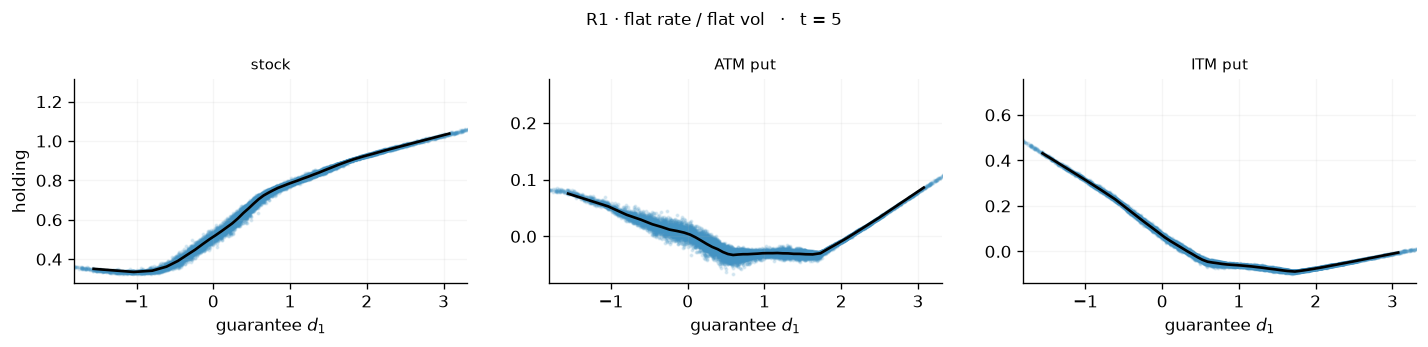

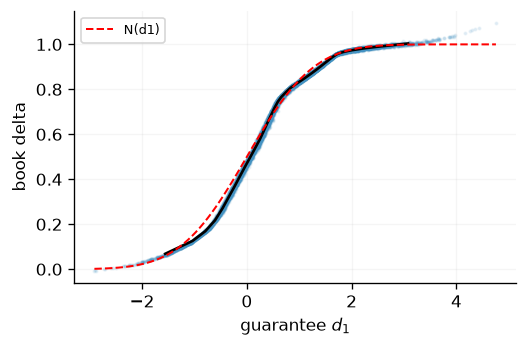

In [3]:
R1 = make_regime("R1", sigma=0.18)
gm_clean = build_contract(R1, "GMAB", "fixed", T=T)      # fixed floor G = P, no mortality
mk = MarketKeys(discount="ois", hazard=None)
gm_clean = GMABAnnuity(
    fund=R1.fund,
    living_floor=GuaranteeFloor([Fixed()], G0=P),
    premium=P,
    maturity=T,
    marketkeys=mk,
    seed=20240601,
)
res = gmab_hedge(R1, gm_clean)
print(f"var kept {res.var_kept:.2%}")

A, G, d1, k, tau = gmab_state(res)
# book delta = stock + per-unit re-struck put deltas
dput = (lambda a: norm.cdf((np.log(1 / a) + (R1.r + R1.sigma**2 / 2) * TENOR)
                           / (R1.sigma * np.sqrt(TENOR))) - 1)
w = np.array([1.0, dput(1.00), dput(1.05)])
book = (res.diag["holdings"][:, k, :].numpy().T * w).sum(1)

plot_vs(res, res.labels, x=d1, xlabel="guarantee $d_1$", k=k)
fig, ax = plt.subplots(figsize=(4.5, 3))
cx, cy = binned(d1, book)
ax.scatter(d1, book, s=2, alpha=0.1, color=SCATTER, rasterized=True)
ax.plot(cx, cy, "k", lw=1.6)
g = np.linspace(d1.min(), d1.max(), 100)
ax.plot(g, norm.cdf(g), "r--", lw=1.2, label="N(d1)")
ax.set_xlabel("guarantee $d_1$"); ax.set_ylabel("book delta")
ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()


## 2 · Regime sweep — where the spread comes from

Same rider economics, progressively richer worlds. We train one standard deep hedge per
configuration (mirroring `03_regime_deephedge`: loop the worlds, plot the learned
holdings) and read the *cloud of holdings*, never its mean — the within-coordinate
**spread is the object of interest**, not noise to average away.

Four readings, in order:

1. **Holdings vs spot $S_t$ (fixed floor, richer worlds).** Holding the floor fixed and
   piling on state variables (flat → Vasicek rate → Heston vol → stochastic mortality),
   the cloud *widens*. At a fixed spot the book can sit anywhere in a band, because the
   policy is responding to coordinates the spot axis does not show.
2. **The $d_1$ collapse — only path-dependent floors show it.** For the fixed floor the
   guarantee $G$ is constant, so $d_1(A/G,\tau)$ is just a monotone *reparametrization* of
   spot — re-plotting against $d_1$ reveals nothing new (same cloud shape). The collapse is
   genuine only when the floor moves with the path: on the **reset** floor and the
   **ratchet+lapse** world the $A/G$ dispersion is absorbed by the guarantee and the
   holdings tighten onto a function of $d_1$. The residual width that survives is exactly
   the spread injected by rate / vol / mortality — the state a single coordinate still
   misses.
3. **Fixed vs ratchet vs reset, vs $d_1$.** The floor reshapes the geometry. The **fixed**
   floor lets $d_1$ run deep in-the-money; the **ratchet** high-water mark pins $A/G\le 1$
   so $d_1$ is capped near zero (the book stays near full delta); **reset** sits between.
4. **Holdings through time.** The term profile — how each leg's holding (and its spread)
   evolves from inception to maturity — is set by the floor and the surrender option.

The deceased cohort (where mortality is on) is overlaid in red: once the death benefit has
settled the book is forced flat, so those points pin to zero.


In [4]:
# ── spread metric: within-bin std of holdings = cloud width in coordinate x ──
def spread(x, h, nb=15, min_count=25):
    """avg within-bin std of holdings — the 'cloud width' in coordinate x."""
    e = np.quantile(x, np.linspace(0, 1, nb + 1))
    e[-1] += 1e-9
    i = np.clip(np.searchsorted(e, x, side="right") - 1, 0, nb - 1)
    s = [h[i == b].std() for b in range(nb) if (i == b).sum() > min_count]
    return float(np.mean(s)) if s else float("nan")


# Same GMAB rider (premium P, 10y). The first four share the FIXED floor and only
# add state variables (rate -> vol -> mortality); the last three swap the floor
# (ratchet / reset) and add surrender. `mixed=True` turns on the lapse (LSMC) leg.
SWEEP = {
    "fixed · gbm / flat": (dict(equity="gbm", rate="flat", hazard=None), "fixed", {}),
    "ratchet · gbm / flat": (dict(equity="gbm", rate="flat", hazard=None), "ratchet", {},),
    "reset · gbm / flat": (dict(equity="gbm", rate="flat", hazard=None), "reset", {}),

    "fixed · gbm / vasicek":                (dict(equity="gbm",    rate="vasicek", hazard=None),    "fixed",   {}),
    "fixed · heston / flat":                (dict(equity="heston", rate="flat",    hazard=None),    "fixed",   {}),
    
    "fixed · gbm / flat · lapse":           (dict(equity="gbm",    rate="flat",    hazard=None),    "fixed", dict(mixed=True, p_S=0.02)),
    "ratchet · gbm / flat · lapse":           (dict(equity="gbm",    rate="flat",    hazard=None),    "ratchet", dict(mixed=True, p_S=0.02)),
}

sweep_res = {}
import gc

print(f"{'config':<40s}{'var kept':>9s}{'spread(S)':>11s}{'spread(d1)':>12s}")
for name, (rkw, floor, ckw) in SWEEP.items():
    reg = make_regime(name, sigma=SIGMA_, **rkw)
    gm = build_contract(reg, "GMAB", floor, T=T, **ckw)
    res = gmab_hedge(reg, gm)
    res.floor, res.cfg = floor, name
    sweep_res[name] = res
    A, G, d1, k, tau = gmab_state(res)
    h = res.diag["holdings"][1, k].numpy()  # ATM put leg
    print(f"{name:<40s}{res.var_kept:>8.1%}{spread(A, h):>11.4f}{spread(d1, h):>12.4f}")
    del reg, gm, res, A, G, d1, h
    gc.collect()




config                                   var kept  spread(S)  spread(d1)
fixed · gbm / flat                          0.2%     0.0095      0.0095
ratchet · gbm / flat                        0.5%     0.0457      0.0301
reset · gbm / flat                          0.5%     0.0505      0.0387
fixed · gbm / vasicek                       0.3%     0.0800      0.0800
fixed · heston / flat                       0.2%     0.0661      0.0661
fixed · gbm / flat · lapse                  0.4%     0.0085      0.0085
ratchet · gbm / flat · lapse                0.6%     0.0447      0.0250


In [32]:
SIGMA_, TENOR_

(0.18, 0.5)

In [33]:
def leg_greeks(alpha, r=R_, sigma=SIGMA_, tenor=TENOR_):
    """Per-unit BSM greeks of a put struck at alpha·S_t, at the S=1 reference
    (same convention as `dput` inside book_delta: S/K = 1/alpha)."""
    s_t = math.sqrt(tenor)
    d1 = (np.log(1.0 / alpha) + (r + 0.5 * sigma**2) * tenor) / (sigma * s_t)
    d2 = d1 - sigma * s_t
    n = math.exp(-0.5 * d1**2) / math.sqrt(2.0 * math.pi)
    return dict(
        delta=norm.cdf(d1) - 1.0,  # put delta            = N(d1) - 1
        gamma=n / (sigma * s_t),  # gamma  @ S=1         = n(d1)/(σ√τ)
        vega=n * s_t,  # vega   @ S=1, per 1.0 vol = n(d1)√τ
        vanna=-n * d2 / sigma,  # vanna                = -n(d1) d2/σ
    )

def book_greeks(hold, *, r=R_, sigma=SIGMA_, tenor=TENOR_, alphas=(1.00, 1.00, 1.05)):
    """hold: (n_legs, n_paths) holdings at ONE rebalance step (e.g.
    res.diag['holdings'][:, k, :].numpy()). Returns dict of (n_paths,) arrays.

    legs: [stock, ATM put (alphas[1]), ITM put (alphas[2])].
    Stock carries delta only (weight 1); the two puts carry the convexity.
    The delta returned here is IDENTICAL to book_delta(hold)."""
    hold = np.asarray(hold)
    gk = [
        None,
        leg_greeks(alphas[1], r, sigma, tenor),
        leg_greeks(alphas[2], r, sigma, tenor),
    ]
    out = {}
    for key in ("delta", "gamma", "vega", "vanna"):
        # stock weight: 1 for delta, 0 for the convexity greeks
        w = np.array([1.0 if key == "delta" else 0.0, gk[1][key], gk[2][key]])
        out[key] = (hold.T * w).sum(1)
    return out

# ── (a) the EMPIRICAL Greek clouds vs d1, mirroring the `richer` holdings loop ──
def plot_greek_cloud(res, greek="gamma", k=None, title="", color=SCATTER):
    """Book `greek` (per path) vs guarantee d1 at step k, on the TRAINED holdings.
    Deceased cohort overlaid in red (forced flat → greek pins to 0)."""
    A, G, d1, k, tau = gmab_state(res, k=k)
    H = res.diag["holdings"][:, k, :].numpy()  # (n_legs, n_paths)
    y = book_greeks(H)[greek]
    dec = deceased_mask(res, k=k, gm=res.target)
    alive = np.ones(len(d1), bool) if dec is None else ~np.asarray(dec)

    fig, ax = plt.subplots(figsize=(5.2, 3.4))
    ax.scatter(d1[alive], y[alive], s=3, alpha=0.16, color=color, rasterized=True)
    if dec is not None and (~alive).sum() > 5:
        ax.scatter(
            d1[~alive],
            y[~alive],
            s=6,
            alpha=0.45,
            color=RED,
            label="deceased (settled → flat)",
        )
        ax.legend(fontsize=7, framealpha=0.6)
    cx, lo, md, hi = binned_quantiles(d1, y)
    if len(cx):
        ax.fill_between(cx, lo, hi, color=color, alpha=0.16, lw=0)
        ax.plot(cx, md, color="k", lw=1.6)
    ax.axhline(0, color="k", lw=0.4)
    ax.set_xlim(-3.2, 3.2)
    ax.set_xlabel("guarantee $d_1$")
    ax.set_ylabel(f"book {greek}")
    ax.set_title((title or res.cfg) + f"  ·  book {greek}", fontsize=9)
    fig.tight_layout()



In [99]:

def leg_greeks(alpha, r=R_, sigma=SIGMA_, tenor=TENOR_):
    """Per-unit BSM greeks of a put struck at alpha·S_t, at the S=1 reference
    (same convention as `dput` inside book_delta: S/K = 1/alpha)."""
    s_t = math.sqrt(tenor)
    d1 = (np.log(1.0 / alpha) + (r + 0.5 * sigma**2) * tenor) / (sigma * s_t)
    d2 = d1 - sigma * s_t
    n = math.exp(-0.5 * d1**2) / math.sqrt(2.0 * math.pi)
    return dict(
        delta=norm.cdf(d1) - 1.0,        # put delta            = N(d1) - 1
        gamma=n / (sigma * s_t),         # gamma  @ S=1         = n(d1)/(σ√τ)
        vega=n * s_t,                    # vega   @ S=1, per 1.0 vol = n(d1)√τ
        vanna=-n * d2 / sigma,           # vanna                = -n(d1) d2/σ
    )
 
 
def book_greeks(hold, *, r=R_, sigma=SIGMA_, tenor=TENOR_,
                alphas=(1.00, 1.00, 1.05)):
    """hold: (n_legs, n_paths) holdings at ONE rebalance step (e.g.
    res.diag['holdings'][:, k, :].numpy()). Returns dict of (n_paths,) arrays.
 
    legs: [stock, ATM put (alphas[1]), ITM put (alphas[2])].
    Stock carries delta only (weight 1); the two puts carry the convexity.
    The delta returned here is IDENTICAL to book_delta(hold)."""
    hold = np.asarray(hold)
    gk = [None, leg_greeks(alphas[1], r, sigma, tenor),
                leg_greeks(alphas[2], r, sigma, tenor)]
    out = {}
    for key in ("delta", "gamma", "vega", "vanna"):
        # stock weight: 1 for delta, 0 for the convexity greeks
        w = np.array([1.0 if key == "delta" else 0.0,
                      gk[1][key], gk[2][key]])
        out[key] = (hold.T * w).sum(1)
    return out
 
 
# ── (a) the EMPIRICAL Greek clouds vs d1, mirroring the `richer` holdings loop ──
def plot_greek_cloud(res, greek="gamma", k=None, title="", color=SCATTER):
    """Book `greek` (per path) vs guarantee d1 at step k, on the TRAINED holdings.
    Deceased cohort overlaid in red (forced flat → greek pins to 0)."""
    A, G, d1, k, tau = gmab_state(res, k=k)
    H = res.diag["holdings"][:, k, :].numpy()           # (n_legs, n_paths)
    y = book_greeks(H)[greek]
    dec = deceased_mask(res, k=k, gm=res.target)
    alive = np.ones(len(d1), bool) if dec is None else ~np.asarray(dec)
 
    fig, ax = plt.subplots(figsize=(5.2, 3.4))
    ax.scatter(d1[alive], y[alive], s=3, alpha=0.16, color=color, rasterized=True)
    if dec is not None and (~alive).sum() > 5:
        ax.scatter(d1[~alive], y[~alive], s=6, alpha=0.45, color=RED,
                   label="deceased (settled → flat)")
        ax.legend(fontsize=7, framealpha=0.6)
    cx, lo, md, hi = binned_quantiles(d1, y)
    if len(cx):
        ax.fill_between(cx, lo, hi, color=color, alpha=0.16, lw=0)
        ax.plot(cx, md, color="k", lw=1.6)
    ax.axhline(0, color="k", lw=0.4)
    ax.set_xlim(-3.2, 3.2)
    ax.set_xlabel("guarantee $d_1$")
    ax.set_ylabel(f"book {greek}")
    ax.set_title((title or res.cfg) + f"  ·  book {greek}", fontsize=9)
    fig.tight_layout()
 
 
def plot_book_greek_compare(floor_res, greek="gamma", k=None,
                            title=None):
    """Overlay book `greek` vs d1 for several trained configs on one axis —
    the direct 'ratchet vs fixed vs reset' (or lapse vs no-lapse) comparison."""
    fig, ax = plt.subplots(figsize=(6.6, 4.4))
    for name, res in floor_res.items():
        #col = FLOOR_COLORS.get(name, LAPSE_COLORS.get(name, SCATTER))
        A, G, d1, kk, tau = gmab_state(res, k=k)
        y = book_greeks(res.diag["holdings"][:, kk, :].numpy())[greek]
        ax.scatter(d1, y, s=3, alpha=0.07, rasterized=True)
        cx, lo, md, hi = binned_quantiles(d1, y)
        if len(cx):
            ax.plot(cx, md, lw=0.4, label=name)

    ax.axhline(0, color="k", lw=0.4, ls='--', alpha=0.5)
    ax.set_xlim(-3.2, 3.2)
    ax.set_xlabel("guarantee $d_1$")
    ax.set_ylabel(f"book {greek}")
    ax.set_title(title or f"book {greek} vs $d_1$ — {greek} geometry by floor",
                 fontsize=10)
    ax.legend(fontsize=8, framealpha=0.6)
    fig.tight_layout()
 
 

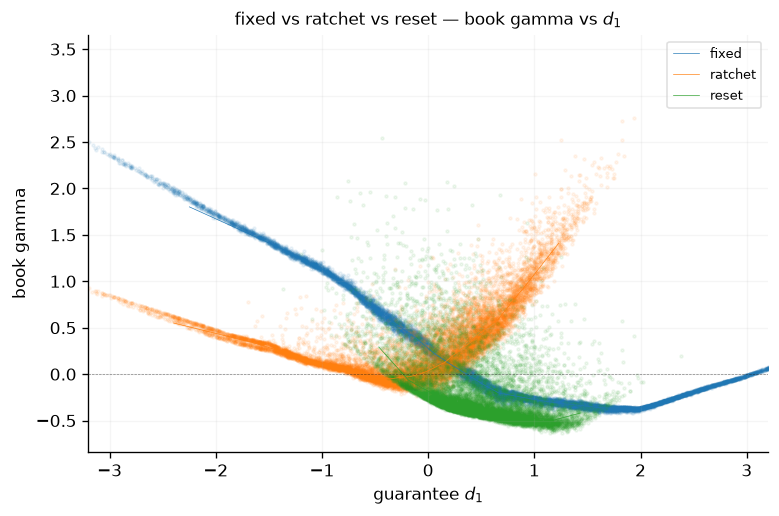

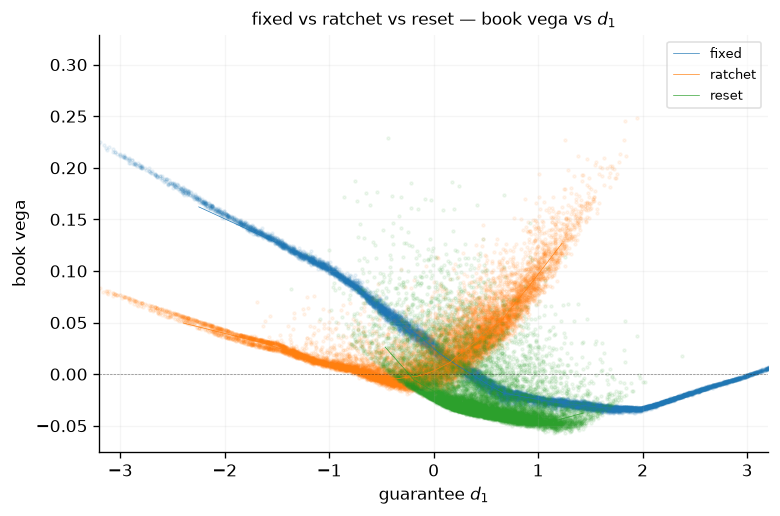

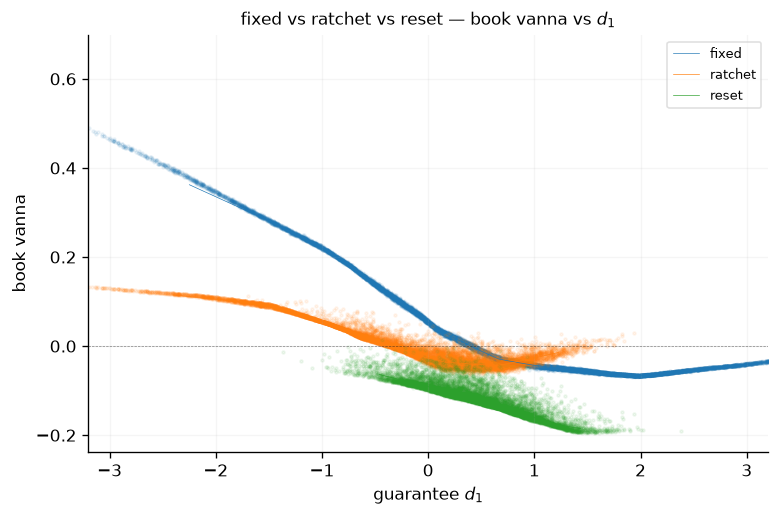

In [100]:
# fixed vs ratchet vs reset — the gamma (and vega / vanna) the desk is short
for g in ("gamma", "vega", "vanna"):
    plot_book_greek_compare({
        "fixed":   sweep_res["fixed · gbm / flat"],
        "ratchet": sweep_res["ratchet · gbm / flat"],
        "reset":   sweep_res["reset · gbm / flat"],
    }, greek=g, k=80,
       title=f"fixed vs ratchet vs reset — book {g} vs $d_1$")
    

In [110]:
def plot_book_greek_compare(floor_res, greek="gamma", k=None,
                            title=None):
    """Overlay book `greek` vs d1 for several trained configs on one axis —
    the direct 'ratchet vs fixed vs reset' (or lapse vs no-lapse) comparison."""
    fig, ax = plt.subplots(figsize=(6.6, 4.4))
    for name, res in floor_res.items():
        #col = FLOOR_COLORS.get(name, LAPSE_COLORS.get(name, SCATTER))
        A, G, d1, kk, tau = gmab_state(res, k=k)
        y = book_greeks(res.diag["holdings"][:, kk, :].numpy())[greek]
        ax.scatter(d1, y, s=3, alpha=0.07, rasterized=True)
        cx, lo, md, hi = binned_quantiles(d1, y)
        if len(cx):
            ax.plot(cx, md, lw=0.4, label=name)

    ax.axhline(0, color="k", lw=0.4, ls='--', alpha=0.5)
    ax.set_xlim(-0.5, 2.2)
    ax.set_ylim(-1,1)
    ax.set_xlabel("guarantee $d_1$")
    ax.set_ylabel(f"book {greek}")
    ax.set_title(title or f"book {greek} vs $d_1$ — {greek} geometry by floor",
                 fontsize=10)
    ax.legend(fontsize=8, framealpha=0.6)
    fig.tight_layout()

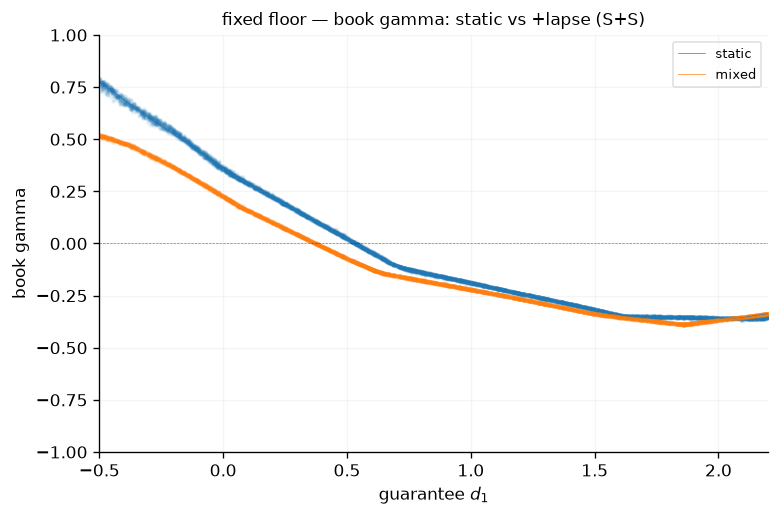

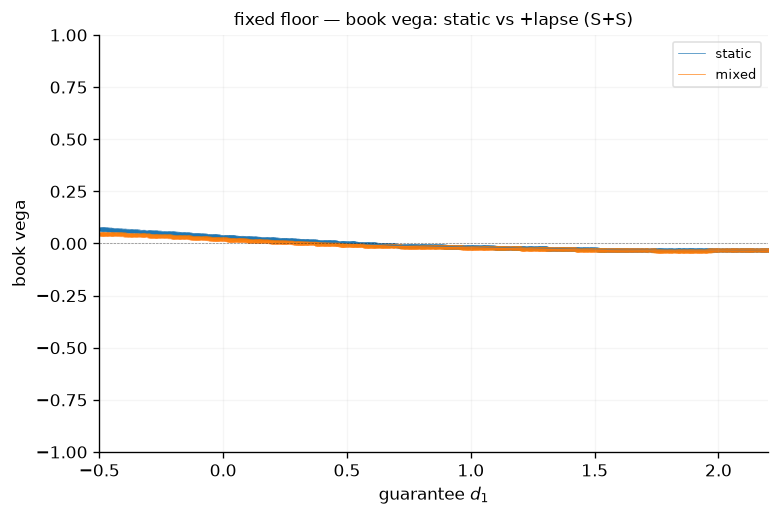

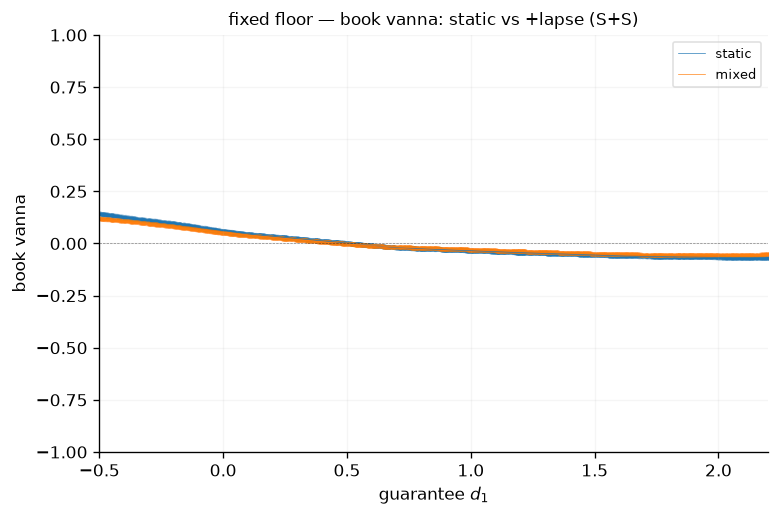

In [111]:
for g in ("gamma","vega","vanna"):
    plot_book_greek_compare({
        "static": sweep_res["fixed · gbm / flat"],
        "mixed":  sweep_res["fixed · gbm / flat · lapse"],
    }, greek=g, k=90,
       title=f"fixed floor — book {g}: static vs +lapse (S+S)")
    

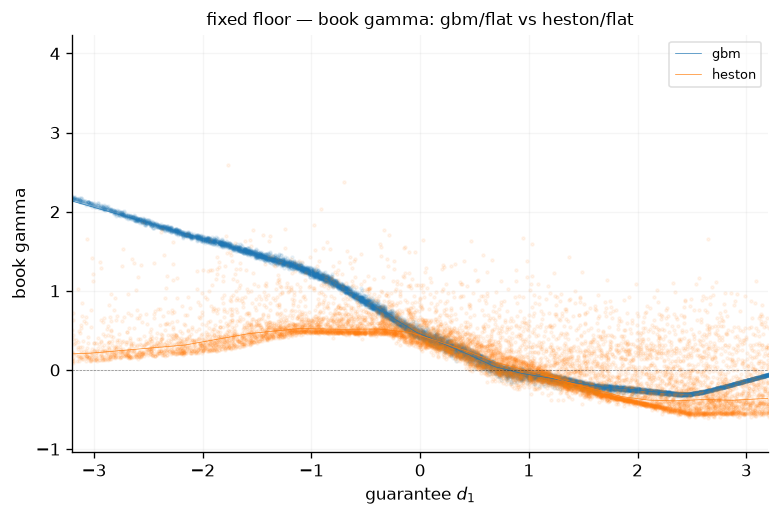

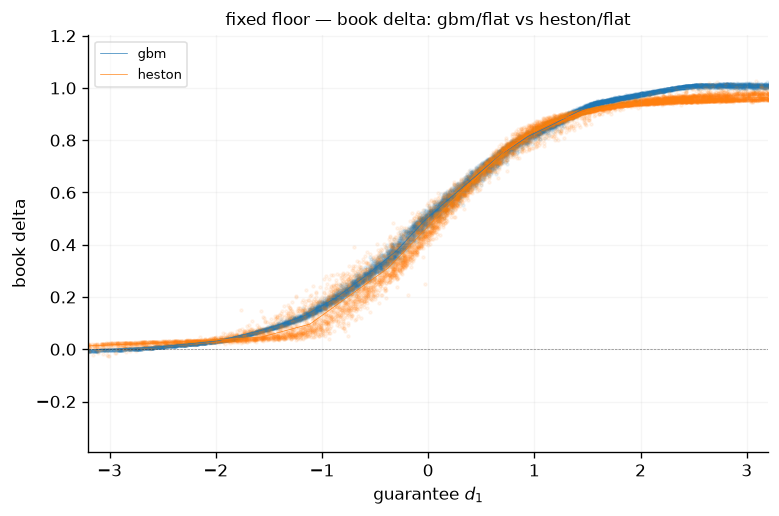

In [104]:
for g in ("gamma","delta"):
    plot_book_greek_compare({
        "gbm": sweep_res["fixed · gbm / flat"],
        "heston":  sweep_res["fixed · heston / flat"],
    }, greek=g, k=100,
       title=f"fixed floor — book {g}: gbm/flat vs heston/flat")

In [80]:
sweep_res.keys()

dict_keys(['fixed · gbm / flat', 'ratchet · gbm / flat', 'reset · gbm / flat', 'fixed · gbm / vasicek', 'fixed · heston / flat', 'fixed · gbm / flat · lapse', 'ratchet · gbm / flat · lapse'])

In [ ]:
fixed · gbm / vasicek                       0.3%     0.0800      0.0800
fixed · heston / flat 

C:\Users\pietr\AppData\Local\Temp\ipykernel_33928\2042198566.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0][0].legend(fontsize=7, markerscale=3, framealpha=0.6)


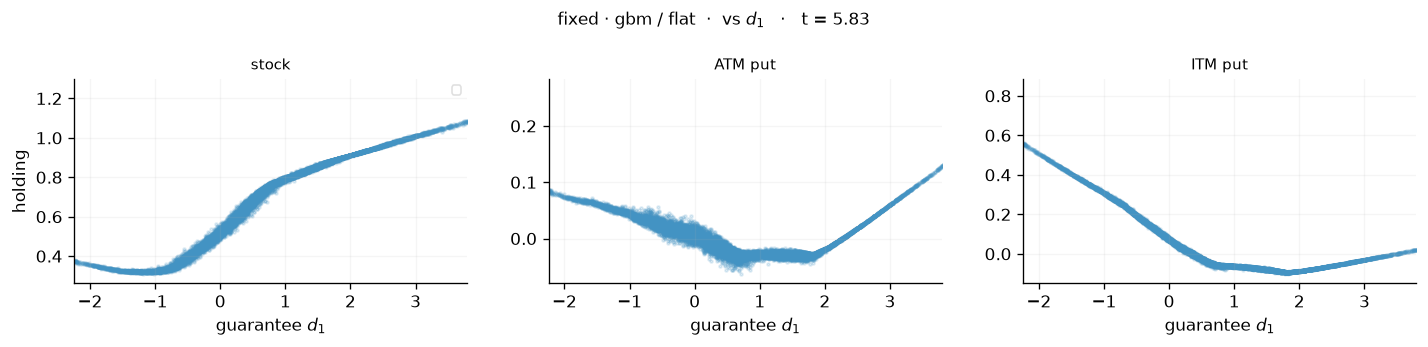

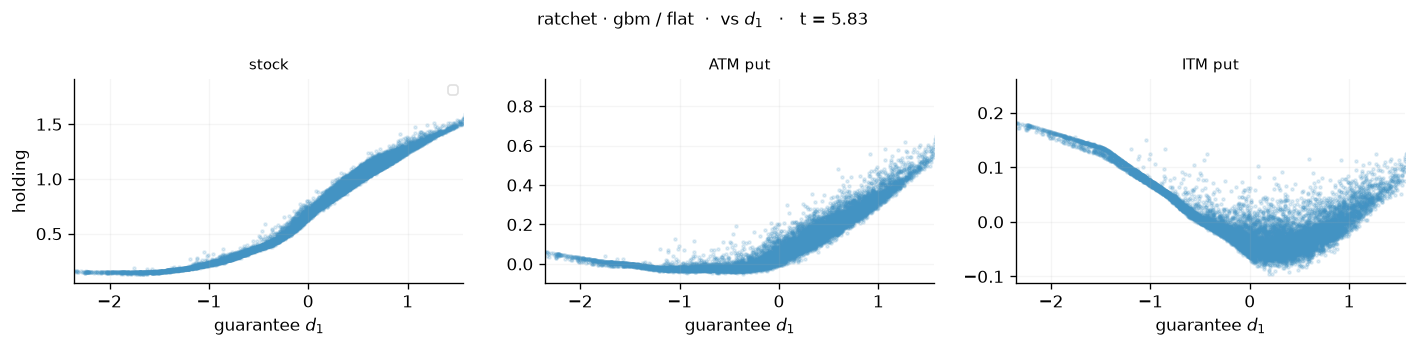

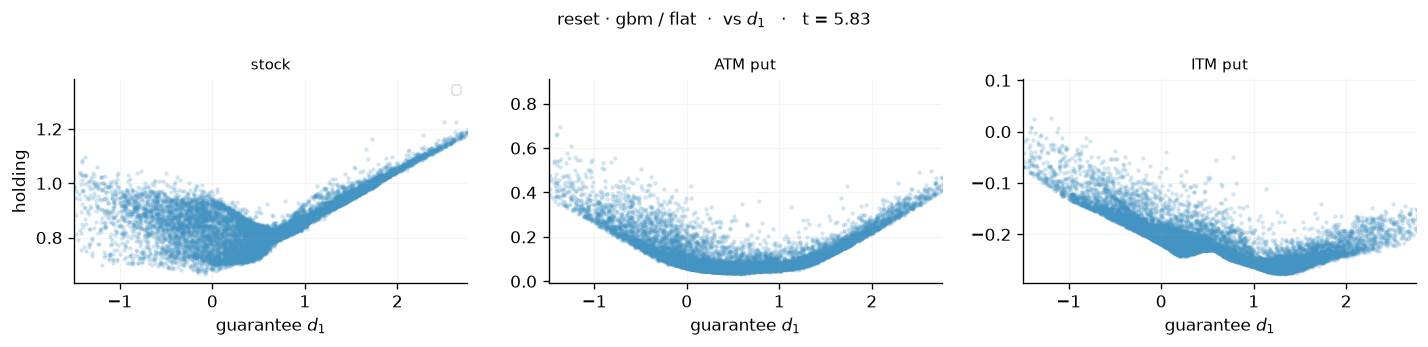

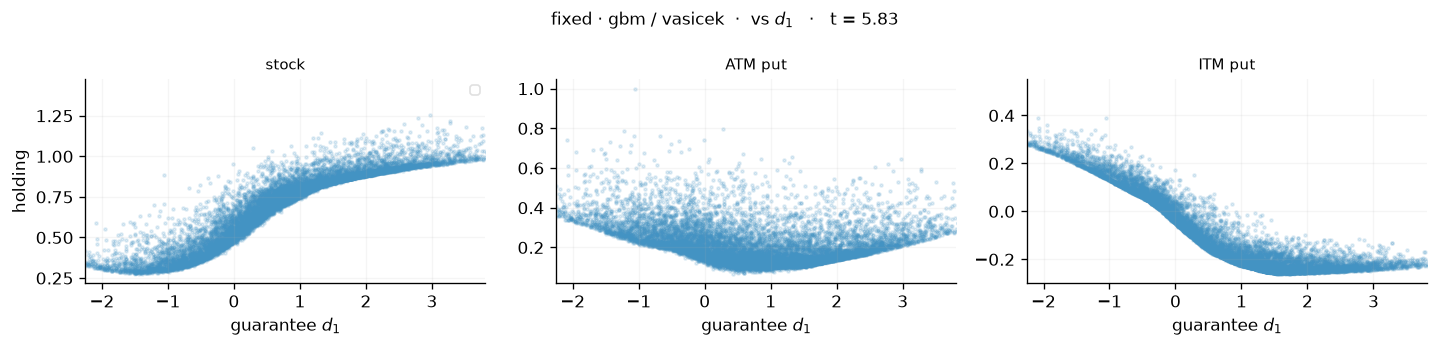

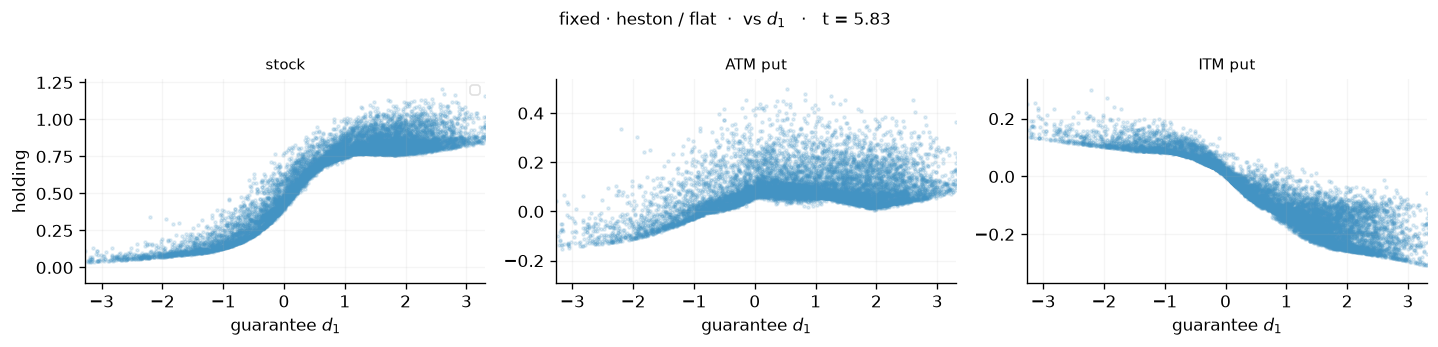

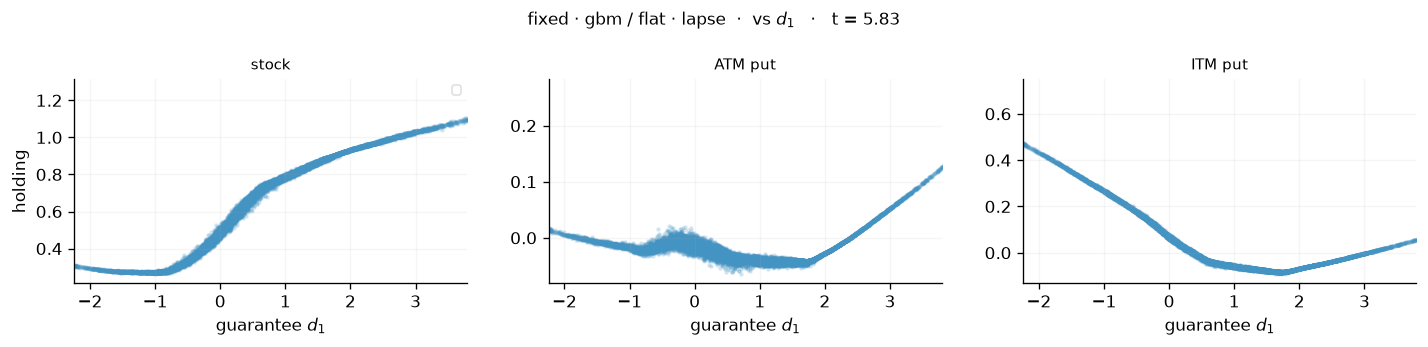

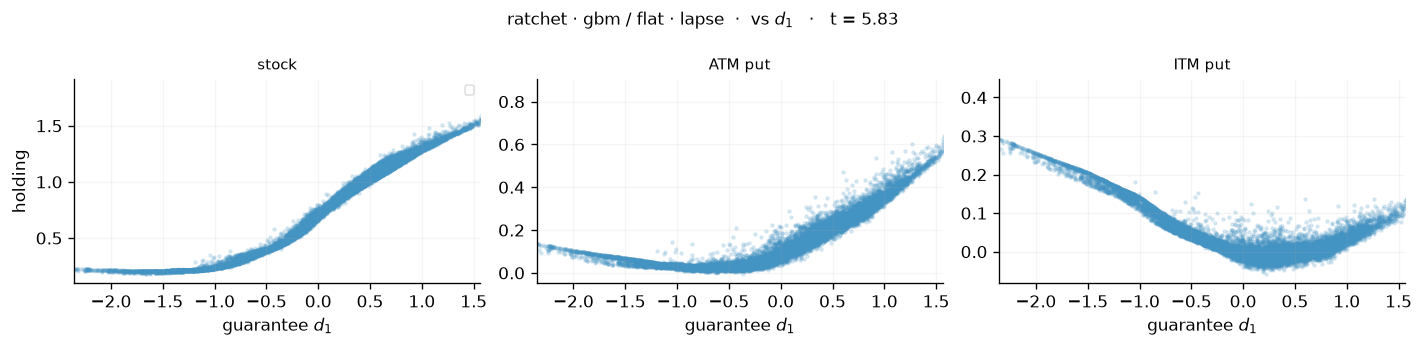

In [5]:
# ── (a) the spread story — holdings vs SPOT widen as state variables pile up ──
richer = [
    "fixed · gbm / flat",
    #"fixed · gbm / vasicek",
    #"fixed · heston / flat",
    #"fixed · heston / vasicek / stoch-mort",
    "ratchet · gbm / flat",
    "reset · gbm / flat",

    "fixed · gbm / vasicek",
    "fixed · heston / flat",

    "fixed · gbm / flat · lapse",
    "ratchet · gbm / flat · lapse",
]

k = 70
for name in richer:
    res = sweep_res[name]
    _, _, d1, k, _ = gmab_state(res, k=k)
    dec = deceased_mask(res, k=k, gm=res.target)
    plot_cloud(res, res.labels, k=k, x=d1, mask=dec, title=name + "  ·  vs $d_1$", xlabel="guarantee $d_1$")



## Observation

A ratchet/reset guarantee is a `max` (or reset) over the account sampled at **discrete anniversary dates** — structurally a discretely-monitored lookback. The hedge tracks ∂V/∂S in *calendar time*, and that derivative is discontinuous across each monitoring date:
 
- **Before the anniversary** the lock-in is pending, so a move in spot moves the guarantee that is about to be locked. The delta carries an impending-ratchet term, ∂(future G)/∂S ≠ 0.
- **After the anniversary** the guarantee is a fixed amount; today's spot no longer moves an already-locked level, so that term is zero.
The value `V` is continuous across the anniversary (no interior cashflow); its delta is not. The fixed floor has no monitoring dates, hence no such term and a continuous delta.
 
∂(future G)/∂S is a real sensitivity, and the desk does carry it — the pre-anniversary delta is genuinely elevated. It is the signature of **short gamma concentrated at the monitoring date**: running into the anniversary the desk buys on the way up / sells on the way down around the at-the-money reference; at the lock the reference resets and the required delta steps to its post-lock value, forcing a rebalancing trade. The sawtooth is the hedge's correct response to a real, discretely-sampled exposure — the gamma "bleed" around anniversaries is a property of the contract, not of the model.
 

In [21]:
def plot_time_scatter(res, title="", max_paths=2000, alpha=0.05):
    """
    Scatter plot of holdings over normalized time.
    Each point is one simulated holding at a given time.

    max_paths: subsample paths to avoid overplotting
    alpha: transparency for density visualization
    """
    H = res.diag["holdings"]  # shape: (n_legs, n_times, n_paths)
    t = (res.diag["open_times"] / res.T).numpy()

    n_legs, n_times, n_paths = H.shape

    # subsample paths if too many
    if n_paths > max_paths:
        idx = torch.randperm(n_paths)[:max_paths]
    else:
        idx = torch.arange(n_paths)

    fig, axes = plt.subplots(
        1, n_legs, figsize=(4 * n_legs, 2.8), squeeze=False
    )

    for j, ax in enumerate(axes[0]):
        h = H[j][:, idx].numpy()  # shape: (n_times, n_sampled_paths)

        # flatten for scatter
        t_rep = np.repeat(t, h.shape[1])
        h_flat = h.reshape(-1)

        ax.scatter(
            t_rep,
            h_flat,
            s=2,
            alpha=alpha,
            color=SCATTER
        )

        ax.set_xlabel("t / T")
        ax.spines[["top", "right"]].set_visible(False)

    axes[0][0].set_ylabel("holding")
    fig.suptitle(title or res.reg.label, fontsize=10)
    fig.tight_layout()

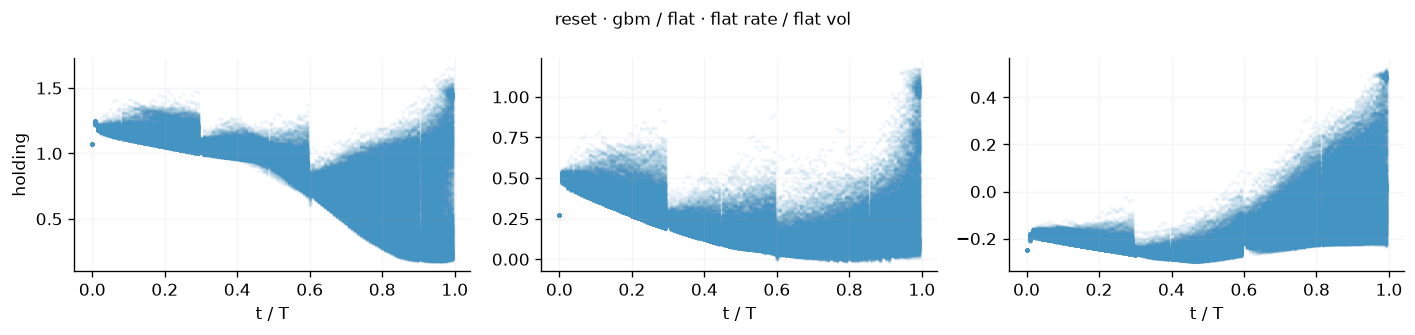

In [24]:
plot_time_scatter(sweep_res['reset · gbm / flat'])

## 5. Model-risk surfaces

The deep hedge is trained once on a **center calibration** (Heston vol σ=18%, Vasicek
mean rate 3%, mortality modal age 80). The trained policy — weights **and** its
calibrated input standardisation — is then frozen and evaluated under **shifted** worlds
with no retraining. For each world we record the hedged-book terminal wealth
`W = center_price + (hedge P&L − liability − costs)`: its mean is the model-risk **bias**,
its 5% CVaR the **tail loss**. A fixed seed across grid points makes each surface a
paired comparison.

center hedger: var_kept=5.42%  price=1.1880


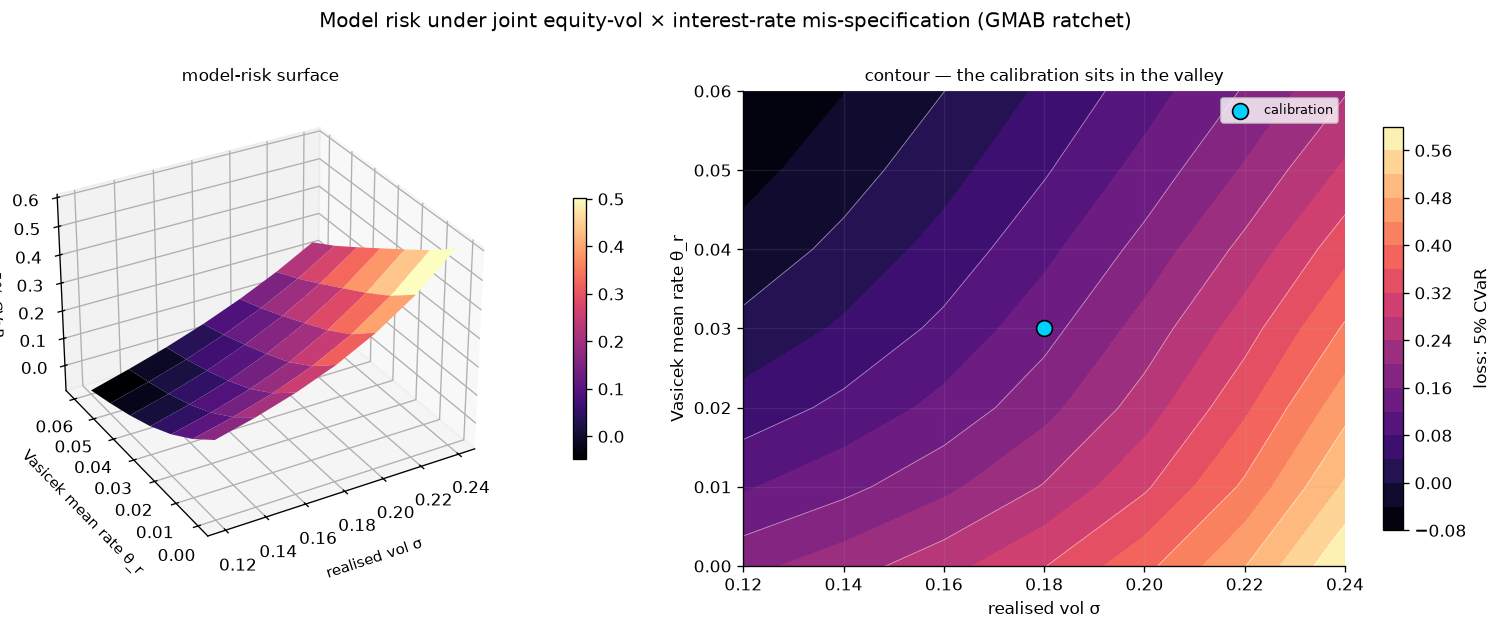

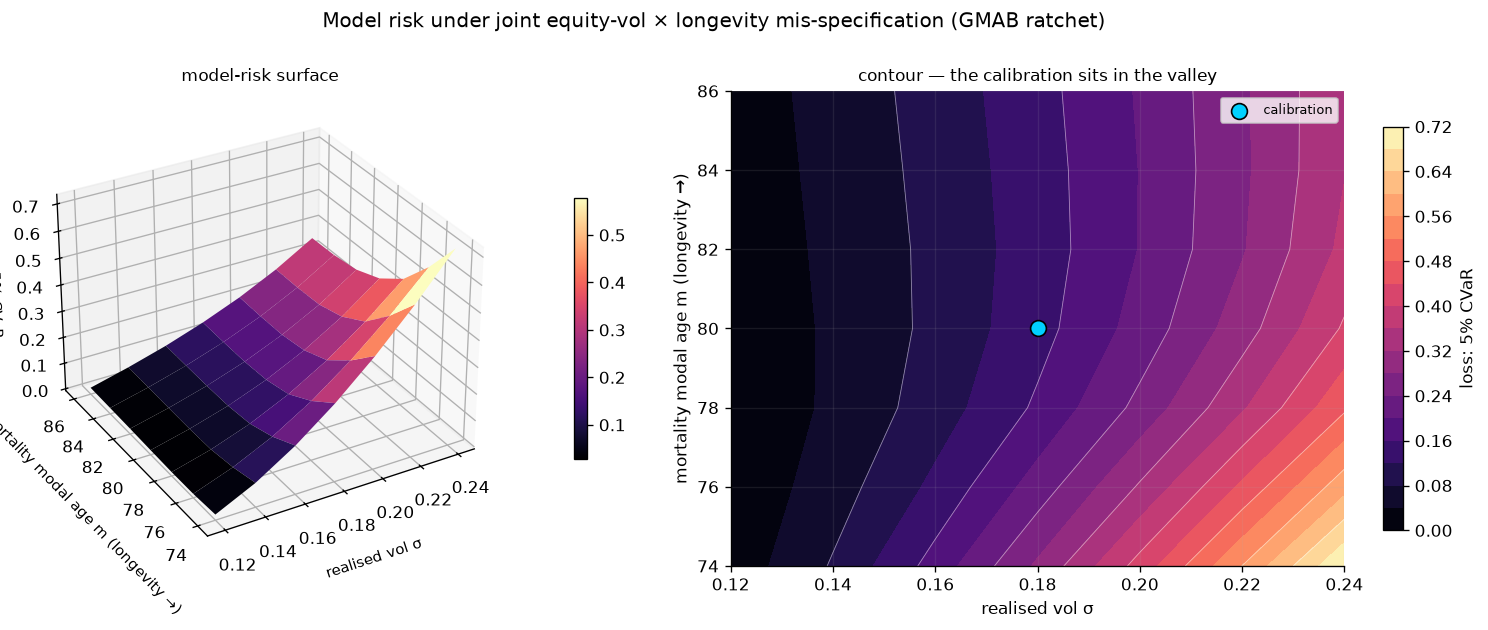

In [11]:
# Model-risk surfaces. Budgets gate on the FAST flag set above (FAST=False is
# paper-grade: a 7×7 grid and a 160-epoch center calibration).
SURF_N = 5 if FAST else 7  # grid resolution per axis
CENTER_EP = 70 if FAST else 160  # center-calibration epochs
SURF_DIAG = 3000 if FAST else 6000  # paths per grid evaluation

center = make_regime(
    "CENTER",
    equity="heston",
    rate="vasicek",
    hazard="stoch",
    sigma=0.18,
    r=0.03,
    m_m=80.0,
)
gm_c = build_contract(center, "GMAB", "ratchet", T=10.0)
res_c = train_hedger(
    center, gm_c, T=10.0, n_paths=2048, n_epochs=CENTER_EP, diag_paths=8000
)
center_price = float(res_c.diag["liability"].mean())
print(f"center hedger: var_kept={res_c.var_kept:.2%}  price={center_price:.4f}")

SEED = 20240601


def evaluate(sigma, theta_v, m):
    reg2 = make_regime(
        "S",
        equity="heston",
        rate="vasicek",
        hazard="stoch",
        sigma=sigma,
        r=0.03,
        h_theta=sigma**2,
        h_v0=sigma**2,
        v_theta=theta_v,
        v_r0=0.03,
        m_m=m,
    )
    gm2 = build_contract(reg2, "GMAB", "ratchet", T=10.0)
    ev = diagnose_under(res_c, reg2, gm2, diag_paths=SURF_DIAG, seed=SEED)
    W = center_price + ev.net
    q05 = np.quantile(W, 0.05)
    return dict(
        meanW=float(W.mean()), stdW=float(W.std()), cvar5=float(W[W <= q05].mean())
    )


def surface(xs, ys, fn):
    M = {k: np.zeros((len(ys), len(xs))) for k in ["meanW", "stdW", "cvar5"]}
    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            r = fn(x, y)
            for k in M:
                M[k][i, j] = r[k]
    return M


sig = np.linspace(0.12, 0.24, SURF_N)
thv = np.linspace(0.00, 0.06, SURF_N)
mm = np.linspace(74, 86, SURF_N)
M_vr = surface(sig, thv, lambda s, t: evaluate(s, t, 80.0))
M_vm = surface(sig, mm, lambda s, m: evaluate(s, 0.03, m))


def surf_fig(xs, ys, M, xlabel, ylabel, center_xy, title):
    X, Y = np.meshgrid(xs, ys)
    Z = -M["cvar5"]
    fig = plt.figure(figsize=(13.5, 5.2))
    ax1 = fig.add_subplot(121, projection="3d")
    s = ax1.plot_surface(X, Y, Z, cmap=cm.magma, edgecolor="none", rstride=1, cstride=1)
    cx, cy = center_xy
    ax1.set_xlabel("\n" + xlabel, fontsize=9)
    ax1.set_ylabel("\n" + ylabel, fontsize=9)
    ax1.set_zlabel("loss: 5% CVaR", fontsize=9)
    ax1.view_init(elev=30, azim=-120)
    ax1.set_title("model-risk surface", fontsize=10)
    fig.colorbar(s, ax=ax1, shrink=0.55, pad=0.10)
    ax2 = fig.add_subplot(122)
    cs = ax2.contourf(X, Y, Z, levels=18, cmap=cm.magma)
    ax2.contour(X, Y, Z, levels=8, colors="white", linewidths=0.5, alpha=0.5)
    ax2.scatter(
        [cx], [cy], color="#00d0ff", s=90, edgecolor="k", zorder=5, label="calibration"
    )
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel(ylabel)
    ax2.set_title("contour — the calibration sits in the valley", fontsize=10)
    ax2.legend(fontsize=8)
    fig.colorbar(cs, ax=ax2, shrink=0.85, label="loss: 5% CVaR")
    fig.suptitle(title, y=1.0)
    fig.tight_layout()
    plt.show()


surf_fig(
    sig,
    thv,
    M_vr,
    "realised vol σ",
    "Vasicek mean rate θ_r",
    (0.18, 0.03),
    "Model risk under joint equity-vol × interest-rate mis-specification (GMAB ratchet)",
)
surf_fig(
    sig,
    mm,
    M_vm,
    "realised vol σ",
    "mortality modal age m (longevity →)",
    (0.18, 80.0),
    "Model risk under joint equity-vol × longevity mis-specification (GMAB ratchet)",
)


The vol×rate contours fan diagonally (both axes matter, vol steeper); the vol×longevity
contours are nearly **vertical** — the visual proof that mortality mis-specification is
second-order to equity-vol. The signed P&L bias is a tilted plane: the desk profits when
realised vol comes in below calibration and loses when it overshoots.

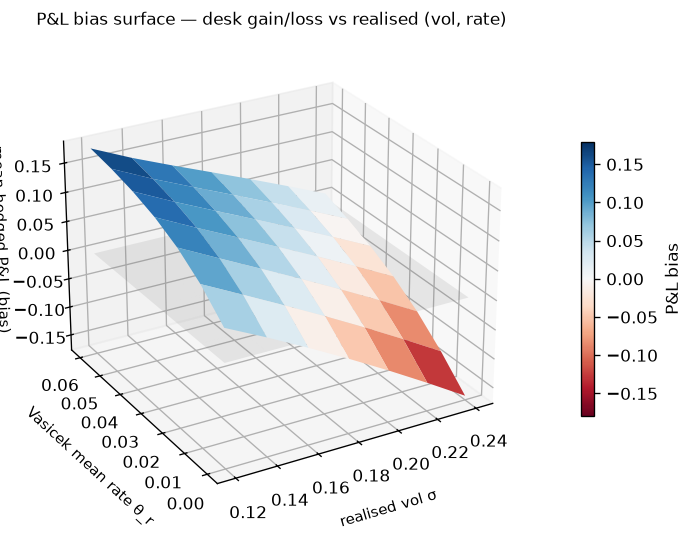

In [14]:
X, Y = np.meshgrid(sig, thv); Z = M_vr["meanW"]; vmax = np.abs(Z).max()
fig = plt.figure(figsize=(7.0, 5.4)); ax = fig.add_subplot(111, projection="3d")
s = ax.plot_surface(X, Y, Z, cmap=cm.RdBu, vmin=-vmax, vmax=vmax, edgecolor="none", rstride=1, cstride=1)
ax.plot_surface(X, Y, np.zeros_like(Z), color="gray", alpha=0.12)
ax.set_xlabel("\nrealised vol σ", fontsize=9); ax.set_ylabel("\nVasicek mean rate θ_r", fontsize=9)
ax.set_zlabel("mean hedged P&L (bias)", fontsize=9); ax.view_init(elev=26, azim=-120)
ax.set_title("P&L bias surface — desk gain/loss vs realised (vol, rate)", fontsize=10)
fig.colorbar(s, ax=ax, shrink=0.55, pad=0.10, label="P&L bias"); #fig.tight_layout(); plt.show()


## 6. The ranking — 1-D cuts and the tornado

Cutting each axis through the calibration quantifies the asymmetry: vol swings the most,
rates moderate, mortality nearly flat.

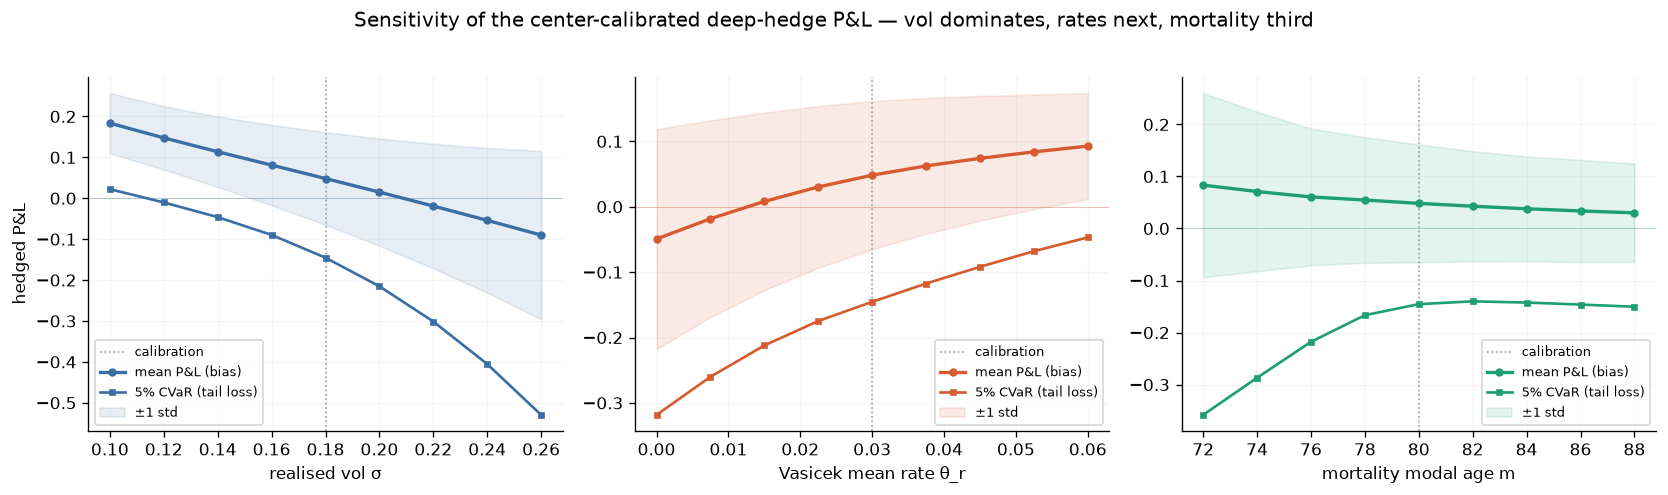

In [13]:
def curve(xs, fn):
    return [evaluate(*fn(x)) for x in xs]


cv_vol = curve(np.linspace(0.10, 0.26, 9), lambda s: (s, 0.03, 80.0))
cv_rat = curve(np.linspace(0.00, 0.06, 9), lambda t: (0.18, t, 80.0))
cv_mor = curve(np.linspace(72, 88, 9), lambda m: (0.18, 0.03, m))
AX = [
    ("realised vol σ", np.linspace(0.10, 0.26, 9), 0.18, cv_vol, BLUE),
    ("Vasicek mean rate θ_r", np.linspace(0.00, 0.06, 9), 0.03, cv_rat, ORANGE),
    ("mortality modal age m", np.linspace(72, 88, 9), 80.0, cv_mor, GREEN),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (lab, xs, c0, rows, col) in zip(axes, AX):
    meanW = np.array([r["meanW"] for r in rows])
    stdW = np.array([r["stdW"] for r in rows])
    cvar = np.array([r["cvar5"] for r in rows])
    ax.axhline(0, color=col, lw=0.5, alpha=0.4)
    ax.axvline(c0, color=GREY, lw=1.0, ls=":", label="calibration")
    ax.plot(xs, meanW, "-o", color=col, lw=2, ms=4, label="mean P&L (bias)")
    ax.plot(xs, cvar, "-s", color=col, lw=1.6, ms=3, label="5% CVaR (tail loss)")
    ax.fill_between(
        xs, meanW - stdW, meanW + stdW, color=col, alpha=0.12, label="±1 std"
    )
    ax.set_xlabel(lab)
    ax.legend(fontsize=7.5)
axes[0].set_ylabel("hedged P&L")
fig.suptitle(
    "Sensitivity of the center-calibrated deep-hedge P&L — vol dominates, rates next, mortality third",
    y=1.02,
)
fig.tight_layout()
plt.show()


### Takeaway

The deep hedge is correct where it can be checked (`N(d₁)`), learns the right
product/floor/lapse holdings across the whole GMxB family, and is liveness-gated on the
deceased cohort. Turned into a model-risk instrument it delivers a clean, decision-grade
map: **the binding risk for a GMxB hedging desk is equity volatility, then rates, with
mortality a distant third** — read straight off the surfaces.

*Method note.* The policy is calibrated on the center world and evaluated under shifted
realised dynamics with honest marks; only the hedging rule (network + standardiser) is
held fixed. The Heston shift moves the realised variance level; the Vasicek shift moves
the mean-reversion target; the mortality shift moves the Gompertz modal age.